# 09b — GHG Protocol worked examples

This notebook covers Chapter 9's `chap9_carbon_scope*.m` scripts: a set of
small worked examples applying GHG Protocol Scope 1/2/3 corporate carbon
accounting methodology, plus two real-data sections (EU electricity grid
emission factors, and a CDP panel comparing location-based vs
market-based Scope 2 reporting).

`chap9_carbon_scope7.m` is a byte-for-byte duplicate of `chap9_carbon_
scope5.m` (only a variable-name spelling fix, `Luxemburg` -> `Luxembourg`,
with identical numeric output) and is not built as a separate section.
`chap9_carbon_scope6.m`, `8.m`, `9.m`, and `12.m` do not exist in the
shipped archive (contrary to an earlier filename-based estimate) — the
chapter's `scope*` scripts run `1-5, 7, 10, 11` only.

All monetary/emissions figures below are the source script's own
illustrative or real-data values; no numbers are invented here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"
plt.rcParams["figure.dpi"] = 100

## 1. Scope 1/2/3 disclosure shares (`chap9_carbon_scope1.m`)

A small worked example computing what share one emissions category is of
another, given three raw disclosure numbers. The source script's own
comment-free numbers are reproduced as-is: two single ratios, then a
2-row x 3-column table where column 3 is the sum of columns 1 and 2
(confirmed: `1336.67 + 2966.52 = 4303.19 ~= 4303.18`), so the third ratio
is "category 2 as a share of (category 1 + category 2)" for two
different reporting entities/years.

In [2]:
r1 = 100 * 50931 / 51750
r2 = 100 * 81.30 / 51750
print(f"Ratio 1: {r1:.2f}%")
print(f"Ratio 2: {r2:.2f}%")

data = np.array([
    [1336.67, 2966.52, 4303.18],
    [2351.00, 4763.15, 7114.15],
])
r3 = 100 * data[:, 1] / data[:, 2]
df1 = pd.DataFrame(data, columns=["Category 1", "Category 2", "Total (1+2)"])
df1["Category 2 / Total (%)"] = r3.round(2)
df1

Ratio 1: 98.42%
Ratio 2: 0.16%


,Category 1,Category 2,Total (1+2),Category 2 / Total (%)
0,1336.67,2966.52,4303.18,68.94
1,2351.00,4763.15,7114.15,66.95


## 2. Scope 2 location-based calculation (`chap9_carbon_scope2.m`)

The textbook Scope 2 formula: $CE = \sum_i A_i \times EF_i$, activity
data (e.g. MWh purchased) times a location-based grid emission factor
(e.g. kg CO2/MWh), summed across two purchased-electricity sources with a
60/40 split of a 2000-unit total.

In [3]:
A = 2000
A1, A2 = 0.60 * A, 0.40 * A
EF1, EF2 = 200, 350

CE1 = A1 * EF1 / 1000
CE2 = A2 * EF2 / 1000
CE = CE1 + CE2

df2 = pd.DataFrame({
    "Source": ["Source 1 (60%)", "Source 2 (40%)", "Total"],
    "Activity (A)": [A1, A2, A],
    "Emission factor (EF)": [EF1, EF2, np.nan],
    "CE = A x EF / 1000": [CE1, CE2, CE],
})
df2

,Source,Activity (A),Emission factor (EF),CE = A x EF / 1000
0,Source 1 (60%),1200.0,200.0,240.0
1,Source 2 (40%),800.0,350.0,280.0
2,Total,2000.0,NaN,520.0


## 3. Scope 3 activity data from a spend/intensity-based emission factor (`chap9_carbon_scope3.m`)

The reverse of section 2: given a total carbon estimate `CE` and an
emission factor `EF` (e.g. tCO2e per unit of spend or per physical
unit), back out the implied activity level `E1 = CE / EF`.

In [4]:
CE = 51750265
EF = 0.227

E1 = CE / EF
E2 = E1 / 1e6

df3 = pd.DataFrame({
    "Quantity": ["Implied activity (E1)", "Implied activity, millions (E2)"],
    "Value": [round(E1, 1), round(E2, 1)],
})
df3

,Quantity,Value
0,Implied activity (E1),227974735.7
1,"Implied activity, millions (E2)",228.0


## 4. EU electricity grid emission factors by country, 1990-2022 (`chap9_carbon_scope4.m`)

Real data: the EEA's greenhouse gas emission intensity of electricity
generation, `chap9_EF_scope2_LB1.xlsx` (location-based Scope 2 emission
factors, g CO2/kWh). Reproduces the source figure comparing several EU
member states plus the EU-27 average.

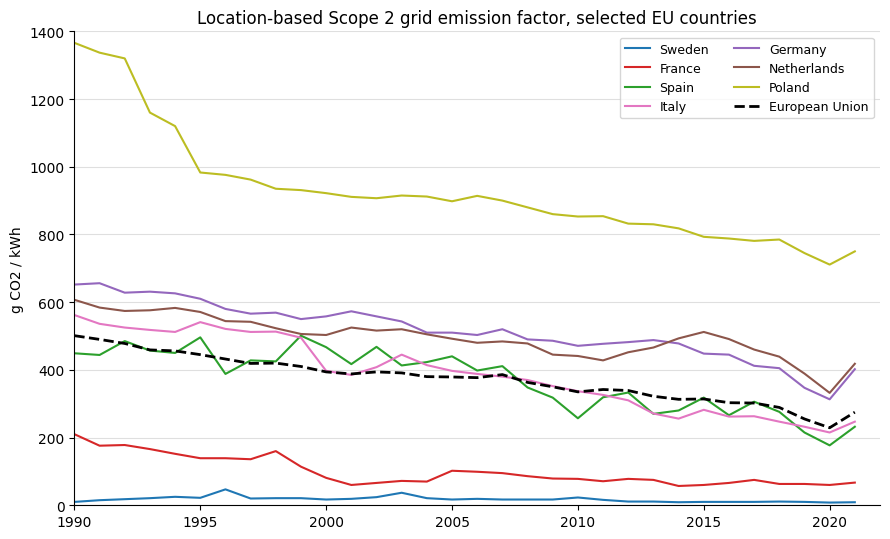

In [5]:
ef_raw = pd.read_excel(f"{DATA_DIR}/chap9_EF_scope2_LB1.xlsx",
                       sheet_name="co2-emission-intensity-12", header=None)
ef_raw.columns = ["year", "country", "EF", "high", "low"]
ef = ef_raw.iloc[1:].reset_index(drop=True)
ef["year"] = pd.to_numeric(ef["year"])
ef["EF"] = pd.to_numeric(ef["EF"])

selected = ["Sweden", "France", "Spain", "Italy", "Germany", "Netherlands", "Poland", "EU-27"]
colours = {
    "Sweden": "tab:blue", "France": "tab:red", "Spain": "tab:green",
    "Italy": "tab:pink", "Germany": "tab:purple", "Netherlands": "tab:brown",
    "Poland": "tab:olive", "EU-27": "black",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for country in selected:
    sub = ef[ef["country"] == country].sort_values("year")
    if country == "EU-27":
        ax.plot(sub["year"], sub["EF"], "--", color=colours[country], linewidth=2.0, label="European Union")
    else:
        ax.plot(sub["year"], sub["EF"], "-", color=colours[country], linewidth=1.5, label=country)

ax.set_xlim(1990, 2022)
ax.set_xticks(range(1990, 2023, 5))
ax.set_ylim(0, 1400)
ax.set_ylabel("g CO2 / kWh")
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9, ncol=2, loc="upper right")
ax.set_title("Location-based Scope 2 grid emission factor, selected EU countries")
plt.tight_layout()
plt.show()

## 5. Country-level Scope 2 emissions from allocation shares (`chap9_carbon_scope5.m`)

A worked example allocating a total activity level `A` across countries
by share `p`, then computing total carbon emissions three ways: using
the World average emission factor, the EU average emission factor, and
each country's own emission factor. (`chap9_carbon_scope7.m` reproduces
this identical computation and is not built separately — see the note at
the top of this notebook.)

In [6]:
country = ["Belgium", "France", "Germany", "Ireland", "Italy", "Luxembourg", "Netherlands",
           "Portugal", "Spain", "Switzerland", "UK", "World"]

EF = np.array([143, 58, 354, 402, 226, 68, 331, 183, 169, 47, 270, 442], dtype=float)
EF_EU = 275
EF_World = 442

A_total = 2013268
p = np.array([0.07, 0.63, 0.04, 0.07, 0.11, 0.0184, 0.0101, 0.007, 0.034, 0.0407, 0.069, 0.021])
p = p / p.sum()
A = np.round(A_total * p)

df5 = pd.DataFrame({"Country": country, "Activity data (A)": A.astype(int)})
display(df5)
print(f"\nsum(Activity data) = {A.sum():,.2f}")

CE_world = np.sum(1000 * A * EF_World)
CE_eu = np.sum(1000 * A * EF_EU)
CE_country = np.sum(1000 * A * EF)

print(f"\nCE (World EF)   = {CE_world:,.2f}  ->  {CE_world/1e9:,.2f} GtCO2e-equivalent-scale")
print(f"CE (EU EF)      = {CE_eu:,.2f}  ->  {CE_eu/1e9:,.2f}")
print(f"CE (country EF) = {CE_country:,.2f}  ->  {CE_country/1e9:,.2f}")

,Country,Activity data (A)
0,Belgium,125807
1,France,1132261
2,Germany,71890
3,Ireland,125807
4,Italy,197696
5,Luxembourg,33069
6,Netherlands,18152
7,Portugal,12581
8,Spain,61106
9,Switzerland,73148



sum(Activity data) = 2,013,269.00

CE (World EF)   = 889,864,898,000.00  ->  889.86 GtCO2e-equivalent-scale
CE (EU EF)      = 553,648,975,000.00  ->  553.65
CE (country EF) = 278,853,170,000.00  ->  278.85


## 6. Location-based vs market-based Scope 2 reporting (`chap9_carbon_scope10.m`)

Real data: a CDP-style disclosure panel, `chap9_CDP2.xlsx`, giving each
reporting entity's Scope 2 emissions computed both ways — location-based
(grid-average) and market-based (contractual instruments, e.g. RECs/PPAs).
The source script computes the incidence of zero-reporting, the direction
of the location-vs-market gap, and its average relative size.

In [7]:
cdp = pd.read_excel(f"{DATA_DIR}/chap9_CDP2.xlsx", sheet_name="Feuil1")
cdp.columns = ["ticker", "organization", "start", "end", "scope2_location", "scope2_market"]
for c in ["scope2_location", "scope2_market"]:
    cdp[c] = pd.to_numeric(cdp[c], errors="coerce")
cdp = cdp.dropna(subset=["scope2_location", "scope2_market"]).reset_index(drop=True)

s1, s2 = cdp["scope2_location"].values, cdp["scope2_market"].values

z1 = np.mean(s1 == 0)
z2 = np.mean((s1 == 0) & (s2 == 0))
z3 = np.mean(s2 == 0)
print("Share reporting zero Scope 2 (location-based)               :", round(100 * z1, 2), "%")
print("Share reporting zero on BOTH bases                           :", round(100 * z2, 2), "%")
print("Share reporting zero Scope 2 (market-based)                  :", round(100 * z3, 2), "%\n")

d = s1 - s2
m1, m2, m3 = np.mean(d > 0), np.mean(d == 0), np.mean(d < 0)
print("Share where location-based > market-based                    :", round(100 * m1, 2), "%")
print("Share where location-based == market-based                   :", round(100 * m2, 2), "%")
print("Share where location-based < market-based                    :", round(100 * m3, 2), "%\n")

mx = np.maximum(s1, s2)
cnd = mx > 0
d0 = np.mean(d[cnd] / mx[cnd])

cnd1 = (d > 0) & (s1 != 0)
d1 = np.mean(d[cnd1] / s1[cnd1])
cnd2 = (d < 0) & (s2 != 0)
d2 = np.mean(d[cnd2] / s2[cnd2])

print("Avg (location-market)/max(location,market)                   :", round(100 * d0, 2), "%")
print("Avg (location-market)/location, where location>market        :", round(100 * d1, 2), "%")
print("Avg (location-market)/market,   where location<market        :", round(100 * d2, 2), "%")

Share reporting zero Scope 2 (location-based)               : 0.84 %
Share reporting zero on BOTH bases                           : 0.4 %
Share reporting zero Scope 2 (market-based)                  : 6.28 %

Share where location-based > market-based                    : 67.56 %
Share where location-based == market-based                   : 11.17 %
Share where location-based < market-based                    : 21.26 %

Avg (location-market)/max(location,market)                   : 21.7 %
Avg (location-market)/location, where location>market        : 39.08 %
Avg (location-market)/market,   where location<market        : -22.54 %


## 7. Financed emissions / portfolio carbon footprint (`chap9_carbon_scope11.m`)

A PCAF-style (Partnership for Carbon Accounting Financials) worked
example: for three portfolio holdings, given market cap under three
scenarios, debt, free-float percentage, and total company emissions
(`CE`), compute Enterprise Value Including Cash (`EVIC = MV + Debt`,
with `MV = MC / FP`), then attribute a portfolio's financed emissions
via `FE = (holding weight / EVIC) x CE` and a weight-based carbon
footprint via `CE_W = (holding weight / MV) x CE`.

In [8]:
MC1 = np.array([12.886, 7.005, 3.271])
MC2 = np.array([10.356, 6.735, 3.287])
MC3 = np.array([10.625, 6.823, 3.474])
Debt = np.array([1.112, 0.000, 0.458])
FP = np.array([0.998, 0.393, 0.967])
CE = np.array([756.144, 23.112, 454.460])

holdings = pd.DataFrame({
    "MC (scenario 1)": MC1, "MC (scenario 2)": MC2, "MC (scenario 3)": MC3,
    "Debt": Debt, "Free float %": FP, "CE": CE,
})
display(holdings.round(3))

MC = np.column_stack([MC1, MC2, MC3])
MV = MC / FP[:, None]
EVIC = 1000 * (MV + Debt[:, None])
MV_scaled = 1000 * MV

evic_df = pd.DataFrame(EVIC, columns=["EVIC (scenario 1)", "EVIC (scenario 2)", "EVIC (scenario 3)"])
display(evic_df.round(0))

W = np.array([63.1, 16.9, 20.0])
FE = (W / EVIC[:, 1]) * CE          # financed emissions, using scenario-2 EVIC
CE_W = (W / MV_scaled[:, 2]) * CE   # weight-based carbon footprint, using scenario-3 MV

results = pd.DataFrame({"Financed emissions (FE)": FE, "Weight-based CE": CE_W})
results.loc["Total"] = results.sum()
results.round(3)

,MC (scenario 1),MC (scenario 2),MC (scenario 3),Debt,Free float %,CE
0,12.886,10.356,10.625,1.112,0.998,756.144
1,7.005,6.735,6.823,0.000,0.393,23.112
2,3.271,3.287,3.474,0.458,0.967,454.460


,EVIC (scenario 1),EVIC (scenario 2),EVIC (scenario 3)
0,14024.0,11489.0,11758.0
1,17824.0,17137.0,17361.0
2,3841.0,3857.0,4051.0


,Financed emissions (FE),Weight-based CE
0,4.153,4.482
1,0.023,0.022
2,2.356,2.530
Total,6.532,7.034
